# 02 - Feature Engineering

Goal: build the early-window feature table (day-1/day-2 cutoff only) for
each of the 607 events, join it against the `severity_class` labels from
`01_data_ingestion.ipynb`, and produce a single train-ready DataFrame for
the GBM (XGBoost) and EBM (InterpretML) baselines in Week 2.

Everything here reads ONLY from the early cutoff window -- reaching into
later days would leak the label, since severity_class is derived from the
full trajectory.

In [1]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path
from flashpoint.db import get_connection

DB_PATH = Path("../data/flashpoint.duckdb")
CUTOFF_DAY = 2  # use the first 2 days as the "early" window

con = get_connection(DB_PATH)
events_df = con.execute("SELECT * FROM events").df()
outcomes_df = con.execute("SELECT * FROM event_outcomes").df()
print(f"{len(events_df)} events, {len(outcomes_df)} outcomes")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

607 events, 607 outcomes


## Step 1: Filter out events too short for the cutoff

An event needs at least `CUTOFF_DAY` days of observations to compute early
features at all -- check for any that don't, per the note flagged at the
end of `01_data_ingestion.ipynb`.

In [2]:
too_short = events_df[events_df['n_days'] < CUTOFF_DAY]
print(f"{len(too_short)} events have fewer than {CUTOFF_DAY} days -- these get dropped")

usable_events = events_df[events_df['n_days'] >= CUTOFF_DAY].copy()
print(f"{len(usable_events)} usable events remain")

0 events have fewer than 2 days -- these get dropped
607 usable events remain


## Step 2: Compute early-window features per event

In [3]:
import pandas as pd
from tqdm import tqdm
from flashpoint.data_access import HDF5Event, read_event_window
from flashpoint.features import early_window_stats

feature_rows = []
for row in tqdm(usable_events.itertuples(), total=len(usable_events)):
    event = HDF5Event(
        event_id=row.event_id, year=row.year, hdf5_path=Path(row.hdf5_path),
        n_days=row.n_days, img_dates=[], lnglat=(row.centroid_lon, row.centroid_lat),
    )
    early_stack = read_event_window(event, 0, CUTOFF_DAY)
    stats = early_window_stats(early_stack)
    stats["event_id"] = row.event_id
    feature_rows.append(stats)

features_df = pd.DataFrame(feature_rows)
features_df.head()


  0%|          | 0/607 [00:00<?, ?it/s]


  1%|          | 5/607 [00:00<00:12, 46.58it/s]


  2%|▏         | 11/607 [00:00<00:11, 52.28it/s]


  3%|▎         | 17/607 [00:00<00:11, 51.39it/s]


  4%|▍         | 24/607 [00:00<00:10, 54.98it/s]

...


 98%|█████████▊| 593/607 [00:09<00:00, 63.70it/s]


 99%|█████████▉| 600/607 [00:09<00:00, 64.02it/s]


100%|██████████| 607/607 [00:09<00:00, 63.74it/s]


100%|██████████| 607/607 [00:09<00:00, 62.20it/s]

,fire_extent_ha,wind_speed_mean,wind_speed_max,wind_direction_sin_mean,wind_direction_cos_mean,max_temp_max,min_temp_min,humidity_min,pdsi_mean,erc_mean,...,slope_max,aspect_sin_mean,aspect_cos_mean,elevation_mean,ndvi_mean,evi2_mean,viirs_m11_mean,viirs_i1_mean,viirs_i2_mean,event_id
0,0.0,0.895985,2.4,-0.354610,-0.385744,294.899994,274.100006,0.00178,-1.642182,52.257618,...,30.107311,-0.068001,0.105162,152.971664,3342.108398,1791.945435,3453.682373,3746.477295,4441.784668,fire_21458798
1,0.0,4.423371,9.5,-0.023865,-0.802851,292.399994,259.299988,0.00131,-2.819414,61.060646,...,56.541397,-0.041087,0.116153,1771.304688,2732.257324,1449.604736,2151.714600,1527.973145,2552.519531,fire_21458801
2,0.0,1.746247,4.0,0.027330,0.047859,295.200012,272.100006,0.00349,-1.862331,26.161974,...,30.107311,0.029064,0.109750,173.749542,3581.161377,1754.474731,4242.986328,4833.382324,5291.138184,fire_21458806
3,112.5,1.051939,2.6,-0.341254,-0.491015,299.399994,271.799988,0.00073,-1.110331,64.648163,...,34.734871,-0.238990,0.112281,221.434708,2987.404541,1747.724121,2533.125244,1705.734741,2900.363037,fire_21458836
4,0.0,4.598395,9.1,-0.122574,-0.069806,287.000000,250.300003,0.00114,-2.819055,49.521889,...,35.807865,0.042856,0.057710,1875.309570,3585.808594,1662.646729,1271.155396,2499.609375,3452.186035,fire_21458848


In [4]:
# NaN check on the new topography/vegetation features -- VIIRS/NDVI/EVI2 can
# be missing for a whole window (clouds). XGBoost handles NaN natively so no
# imputation, but the counts should be looked at, not assumed.
NEW_COLS = [
    "slope_mean", "slope_max", "aspect_sin_mean", "aspect_cos_mean", "elevation_mean",
    "ndvi_mean", "evi2_mean", "viirs_m11_mean", "viirs_i1_mean", "viirs_i2_mean",
]
print(features_df[NEW_COLS].isna().sum())

slope_mean          0
slope_max           0
aspect_sin_mean     0
aspect_cos_mean     0
elevation_mean      0
ndvi_mean          33
evi2_mean          33
viirs_m11_mean      2
viirs_i1_mean       2
viirs_i2_mean       2
dtype: int64


## Step 3: Write early_features to DuckDB, then join with labels

In [5]:
from flashpoint.db import SCHEMA_SQL

# The schema gained the topography/vegetation columns -- CREATE TABLE IF NOT
# EXISTS won't widen an existing table, so drop and recreate. early_features
# is fully derived data rebuilt right here, so nothing is lost.
con.execute("DROP TABLE IF EXISTS early_features")
con.execute(SCHEMA_SQL)

insert_rows = [
    (
        r["event_id"], CUTOFF_DAY, r["fire_extent_ha"], r["wind_speed_mean"],
        r["wind_speed_max"], r["wind_direction_sin_mean"], r["wind_direction_cos_mean"],
        r["max_temp_max"], r["min_temp_min"], r["humidity_min"], r["pdsi_mean"], r["erc_mean"],
        r["slope_mean"], r["slope_max"], r["aspect_sin_mean"], r["aspect_cos_mean"],
        r["elevation_mean"], r["ndvi_mean"], r["evi2_mean"],
        r["viirs_m11_mean"], r["viirs_i1_mean"], r["viirs_i2_mean"],
    )
    for r in feature_rows
]
con.executemany(
    "INSERT OR REPLACE INTO early_features VALUES "
    "(?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)",
    insert_rows,
)
con.commit()

train_df = con.execute("""
    SELECT e.year, f.*, o.severity_class
    FROM early_features f
    JOIN events e ON e.event_id = f.event_id
    JOIN event_outcomes o ON o.event_id = f.event_id
""").df()
print(train_df.shape)
train_df.head()

(607, 24)


,year,event_id,cutoff_day,fire_extent_ha,wind_speed_mean,wind_speed_max,wind_direction_sin_mean,wind_direction_cos_mean,max_temp_max,min_temp_min,...,slope_max,aspect_sin_mean,aspect_cos_mean,elevation_mean,ndvi_mean,evi2_mean,viirs_m11_mean,viirs_i1_mean,viirs_i2_mean,severity_class
0,2018,fire_21458798,2,0.0,0.895985,2.4,-0.354610,-0.385744,294.899994,274.100006,...,30.107311,-0.068001,0.105162,152.971664,3342.108398,1791.945435,3453.682373,3746.477295,4441.784668,0
1,2018,fire_21458801,2,0.0,4.423371,9.5,-0.023865,-0.802851,292.399994,259.299988,...,56.541397,-0.041087,0.116153,1771.304688,2732.257324,1449.604736,2151.714600,1527.973145,2552.519531,0
2,2018,fire_21458806,2,0.0,1.746247,4.0,0.027330,0.047859,295.200012,272.100006,...,30.107311,0.029064,0.109750,173.749542,3581.161377,1754.474731,4242.986328,4833.382324,5291.138184,1
3,2018,fire_21458836,2,112.5,1.051939,2.6,-0.341254,-0.491015,299.399994,271.799988,...,34.734871,-0.238990,0.112281,221.434708,2987.404541,1747.724121,2533.125244,1705.734741,2900.363037,0
4,2018,fire_21458848,2,0.0,4.598395,9.1,-0.122574,-0.069806,287.000000,250.300003,...,35.807865,0.042856,0.057710,1875.309570,3585.808594,1662.646729,1271.155396,2499.609375,3452.186035,0


## Step 4: Year-based train/test split (not random)

Per the paper's own recommendation: yearly distributions vary a lot (2019
is a known outlier -- fewer, smaller fires), so a random shuffle risks an
unrepresentative split. Hold out one full year as the test set instead --
e.g. train on 2018/2020/2021, test on 2019, or run this across a few
held-out years to sanity check stability before committing to one split.

In [6]:
BASE_FEATURE_COLS = [
    "fire_extent_ha", "wind_speed_mean", "wind_speed_max",
    "wind_direction_sin_mean", "wind_direction_cos_mean",
    "max_temp_max", "min_temp_min", "humidity_min", "pdsi_mean", "erc_mean",
]
TOPO_COLS = [
    "slope_mean", "slope_max", "aspect_sin_mean", "aspect_cos_mean", "elevation_mean",
]
VEG_COLS = [
    "ndvi_mean", "evi2_mean", "viirs_m11_mean", "viirs_i1_mean", "viirs_i2_mean",
]
FEATURE_COLS = BASE_FEATURE_COLS + TOPO_COLS + VEG_COLS

TEST_YEAR = 2019  # known outlier year in this dataset -- a good stress test

train = train_df[train_df["year"] != TEST_YEAR]
test = train_df[train_df["year"] == TEST_YEAR]

X_train, y_train = train[FEATURE_COLS], train["severity_class"]
X_test, y_test = test[FEATURE_COLS], test["severity_class"]

print(f"Train: {len(train)} events, Test: {len(test)} events")
print("Train class balance:\n", y_train.value_counts().sort_index())
print("Test class balance:\n", y_test.value_counts().sort_index())

Train: 533 events, Test: 74 events
Train class balance:
 severity_class
0    125
1    123
2    138
3    147
Name: count, dtype: int64
Test class balance:
 severity_class
0    30
1    26
2    14
3     4
Name: count, dtype: int64


## Step 5: XGBoost baseline

In [7]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

xgb_clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    objective="multi:softmax", num_class=4, eval_metric="mlogloss",
    random_state=0,
)
xgb_clf.fit(X_train, y_train)

y_pred = xgb_clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.50      0.58        30
           1       0.40      0.15      0.22        26
           2       0.25      0.50      0.33        14
           3       0.07      0.25      0.11         4

    accuracy                           0.36        74
   macro avg       0.35      0.35      0.31        74
weighted avg       0.47      0.36      0.38        74

[[15  6  4  5]
 [ 2  4 15  5]
 [ 4  0  7  3]
 [ 1  0  2  1]]


## Step 6: EBM baseline (fully interpretable, glass-box)

Trained on the exact same features and split, so its accuracy and its
native explanations are directly comparable to XGBoost + SHAP.

In [8]:
from interpret.glassbox import ExplainableBoostingClassifier

ebm_clf = ExplainableBoostingClassifier(random_state=0)
ebm_clf.fit(X_train, y_train)

y_pred_ebm = ebm_clf.predict(X_test)
print(classification_report(y_test, y_pred_ebm))

/Users/pmacias/opt/anaconda3/envs/flashpoint/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


/Users/pmacias/opt/anaconda3/envs/flashpoint/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:1249: UserWarning: For multiclass we cannot currently visualize pairs and they will be stripped from the global explanations. Set interactions=0 to generate a fully interpretable glassbox model.
  warn(


              precision    recall  f1-score   support

           0       0.68      0.43      0.53        30
           1       0.50      0.31      0.38        26
           2       0.20      0.36      0.26        14
           3       0.07      0.25      0.11         4

    accuracy                           0.36        74
   macro avg       0.36      0.34      0.32        74
weighted avg       0.49      0.36      0.40        74



In [9]:
from sklearn.metrics import accuracy_score, f1_score

years = sorted(train_df["year"].unique())
results = []

for test_year in years:
    tr = train_df[train_df["year"] != test_year]
    te = train_df[train_df["year"] == test_year]
    Xtr, ytr = tr[FEATURE_COLS], tr["severity_class"]
    Xte, yte = te[FEATURE_COLS], te["severity_class"]

    clf = xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        objective="multi:softmax", num_class=4, eval_metric="mlogloss", random_state=0,
    )
    clf.fit(Xtr, ytr)
    preds = clf.predict(Xte)

    results.append({
        "test_year": test_year,
        "n_test": len(te),
        "accuracy": accuracy_score(yte, preds),
        "macro_f1": f1_score(yte, preds, average="macro"),
    })

results_df = pd.DataFrame(results)
print(results_df)
print(f"\nMean accuracy: {results_df['accuracy'].mean():.3f}")
print(f"Mean macro F1: {results_df['macro_f1'].mean():.3f}")

   test_year  n_test  accuracy  macro_f1
0       2018     176  0.380682  0.381395
1       2019      74  0.364865  0.310897
2       2020     201  0.353234  0.351744
3       2021     156  0.448718  0.442702

Mean accuracy: 0.387
Mean macro F1: 0.372


## Step 7: Ablation -- do topography / vegetation features actually help?

Leave-one-year-out XGBoost (same params as above) on four feature sets:
base 10 only, base + topography, base + vegetation, and everything combined.
The "base (10)" row should reproduce the LOYO numbers from the previous cell
as a cross-check.

In [10]:
def loyo_eval(cols):
    """Leave-one-year-out XGBoost over the given feature columns ->
    (mean accuracy, mean macro-F1) across the four held-out years."""
    accs, f1s = [], []
    for test_year in sorted(train_df["year"].unique()):
        tr = train_df[train_df["year"] != test_year]
        te = train_df[train_df["year"] == test_year]
        clf = xgb.XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            objective="multi:softmax", num_class=4, eval_metric="mlogloss", random_state=0,
        )
        clf.fit(tr[cols], tr["severity_class"])
        preds = clf.predict(te[cols])
        accs.append(accuracy_score(te["severity_class"], preds))
        f1s.append(f1_score(te["severity_class"], preds, average="macro"))
    return sum(accs) / len(accs), sum(f1s) / len(f1s)

ablation = {
    "base (10)": BASE_FEATURE_COLS,
    "base + topo": BASE_FEATURE_COLS + TOPO_COLS,
    "base + veg": BASE_FEATURE_COLS + VEG_COLS,
    "base + topo + veg": FEATURE_COLS,
}

ablation_rows = []
for name, cols in ablation.items():
    mean_acc, mean_f1 = loyo_eval(cols)
    ablation_rows.append({
        "feature_set": name,
        "n_features": len(cols),
        "mean_accuracy": mean_acc,
        "mean_macro_f1": mean_f1,
    })

ablation_df = pd.DataFrame(ablation_rows)
print(ablation_df.to_string(index=False))

      feature_set  n_features  mean_accuracy  mean_macro_f1
        base (10)          10       0.343156       0.325892
      base + topo          15       0.393816       0.378251
       base + veg          15       0.352211       0.334524
base + topo + veg          20       0.386875       0.371685


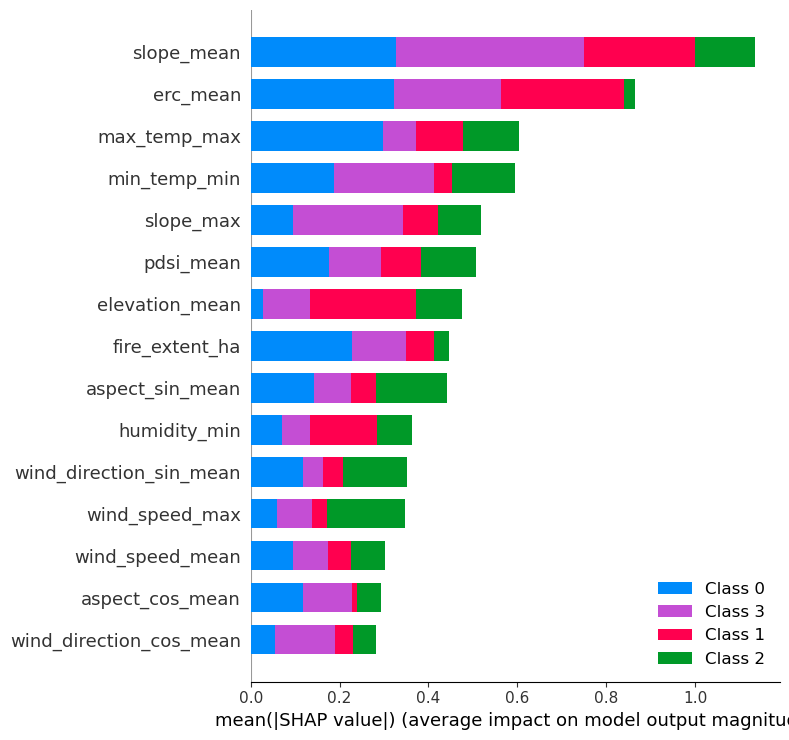

In [11]:
import shap

# SHAP on the ablation's best feature set (base + topo) -- vegetation
# features excluded since they slightly hurt LOYO performance
SHAP_COLS = BASE_FEATURE_COLS + TOPO_COLS

xgb_full = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    objective="multi:softmax", num_class=4, eval_metric="mlogloss", random_state=0,
)
xgb_full.fit(train_df[SHAP_COLS], train_df["severity_class"])

explainer = shap.TreeExplainer(xgb_full)
shap_values = explainer.shap_values(train_df[SHAP_COLS])

shap.summary_plot(shap_values, train_df[SHAP_COLS], plot_type="bar")

## Step 8: EBM on the best feature set -- LOYO eval + native importances

Same 15 features (base + topo) and same leave-one-year-out setup as the
XGBoost model above. `interactions=0` keeps the model mains-only -- the
earlier warning noted multiclass EBMs can't visualize pairs anyway, and it
makes `term_names_` line up 1:1 with the feature list, so the native
`term_importances()` ranking is directly comparable to the SHAP plot.

 test_year  n_test  accuracy  macro_f1
      2018     176  0.426136  0.426268
      2019      74  0.445946  0.409806
      2020     201  0.373134  0.381451
      2021     156  0.416667  0.423197

EBM LOYO mean accuracy: 0.415
EBM LOYO mean macro F1: 0.410



EBM term importances (mean |score|):
slope_mean                 0.202974
erc_mean                   0.137861
max_temp_max               0.103651
fire_extent_ha             0.088037
min_temp_min               0.078854
aspect_sin_mean            0.072591
pdsi_mean                  0.061530
elevation_mean             0.058937
slope_max                  0.055139
wind_direction_sin_mean    0.051205
humidity_min               0.045577
wind_direction_cos_mean    0.042665
wind_speed_max             0.034980
wind_speed_mean            0.027083
aspect_cos_mean            0.021365


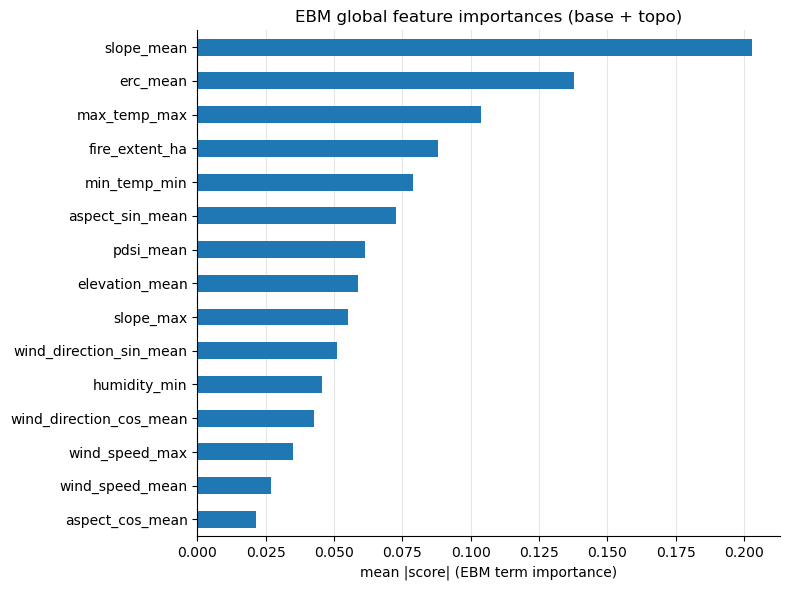

In [12]:
import matplotlib.pyplot as plt

# leave-one-year-out eval, same folds and feature set as the XGBoost SHAP model
ebm_results = []
for test_year in sorted(train_df["year"].unique()):
    tr = train_df[train_df["year"] != test_year]
    te = train_df[train_df["year"] == test_year]
    m = ExplainableBoostingClassifier(interactions=0, random_state=0)
    m.fit(tr[SHAP_COLS], tr["severity_class"])
    preds = m.predict(te[SHAP_COLS])
    ebm_results.append({
        "test_year": test_year,
        "n_test": len(te),
        "accuracy": accuracy_score(te["severity_class"], preds),
        "macro_f1": f1_score(te["severity_class"], preds, average="macro"),
    })

ebm_results_df = pd.DataFrame(ebm_results)
print(ebm_results_df.to_string(index=False))
print(f"\nEBM LOYO mean accuracy: {ebm_results_df['accuracy'].mean():.3f}")
print(f"EBM LOYO mean macro F1: {ebm_results_df['macro_f1'].mean():.3f}")

# native global importances from an EBM trained on all events -- mirrors the
# SHAP cell, where xgb_full is also fit on the full dataset for explanation
ebm_full = ExplainableBoostingClassifier(interactions=0, random_state=0)
ebm_full.fit(train_df[SHAP_COLS], train_df["severity_class"])

ebm_importances = pd.Series(
    ebm_full.term_importances(), index=ebm_full.term_names_
).sort_values(ascending=False)
print("\nEBM term importances (mean |score|):")
print(ebm_importances.to_string())

fig, ax = plt.subplots(figsize=(8, 6))
ebm_importances.iloc[::-1].plot.barh(ax=ax, color="#1f77b4")
ax.set_xlabel("mean |score| (EBM term importance)")
ax.set_title("EBM global feature importances (base + topo)")
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(True, color="0.9")
ax.set_axisbelow(True)
plt.tight_layout()

In [13]:
import sys, numpy
print(sys.executable)
print(numpy.__version__)

/Users/pmacias/opt/anaconda3/envs/flashpoint/bin/python
2.3.5


In [14]:
con.close()